In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, f1_score
from preprocessing import get_features_and_target
from visualizer import plot_visualizer, plot_visualizer_classification
import plotly.graph_objects as go
from sklearn.model_selection import StratifiedKFold
from preprocessing import get_features_and_target_classification
from tabpfn import TabPFNClassifier, TabPFNRegressor
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from xgboost import XGBRegressor

In [2]:
import huggingface_hub
huggingface_hub.login()

# Getting Dataframe

In [3]:
# Load the training and development datasets
train_df = pd.read_csv("data/train_data.csv")
dev_df = pd.read_csv("data/development_data.csv")
#sc = StandardScaler()

target_column_class = "Category" 

x_train, y_train  = get_features_and_target(train_df, target_column_class)
x_dev, y_dev = get_features_and_target(dev_df, target_column_class)

#x_train = sc.fit_transform(X=x_train)
#x_dev = sc.transform(x_dev)

# Defining Model

In [4]:
#model = 'XGBoost'
model = 'TabPFNClassifier'

In [5]:
x_train

,Pressure (PSI),Welding Time (ms),Angle (Deg),Force (N),Current (A),Thickness A (mm),Thickness B (mm)
0,35,200,0,6.82,1081.47,0.922,0.920
1,35,1500,0,52.25,2014.73,0.920,0.925
2,95,200,0,16.57,1321.93,0.912,0.924
3,95,200,0,41.42,1615.83,0.948,0.939
4,35,1500,0,63.82,1137.29,0.930,0.937
...,...,...,...,...,...,...,...
290,60,1200,0,98.51,4429.61,0.625,0.622
291,60,1200,0,97.32,2636.69,0.622,0.632
292,60,1200,0,98.07,3601.67,0.666,0.633
293,60,1200,0,97.09,4161.74,0.615,0.619


# Add Physical Columns Interfacial_Failure and Pullout_Failure

In [6]:
def compute_interfacial_failure(df):
     t = df[['Thickness A (mm)', 'Thickness B (mm)']].min(axis=1) 
     f_pull = 1 * (np.pi/4) * (4 * np.sqrt(t))**2 * (0.7 * 365) 
     return np.round(f_pull, 1) 

def compute_pullout_failure(df):
     t = df[['Thickness A (mm)', 'Thickness B (mm)']].min(axis=1) 
     x = df[['Thickness A (mm)', 'Thickness B (mm)']].sum(axis=1)
     # x can be approximated to metal sheet thickness. Change 2*t either to t to use the thinner 
     # metal sheet or 2*x to test if the sum of both metal sheets give beter results
     f_pull = np.pi * ((4 * np.sqrt(t)) + 2*t)*t*365 
     return np.round(f_pull, 1) 

In [7]:
x_dev

,Pressure (PSI),Welding Time (ms),Angle (Deg),Force (N),Current (A),Thickness A (mm),Thickness B (mm)
0,95,1500,0,124.19,1045.90,0.918,0.925
1,35,200,0,6.58,1171.55,0.931,0.922
2,95,1500,0,124.16,1078.29,0.925,0.930
3,35,200,0,6.61,916.16,0.936,0.927
4,35,1500,15,54.11,1440.24,0.930,0.946
...,...,...,...,...,...,...,...
94,60,1200,0,97.26,3624.99,0.624,0.627
95,60,1200,0,97.29,4311.15,0.623,0.630
96,60,1200,0,98.26,3490.11,0.627,0.626
97,60,1200,0,98.15,3311.58,0.619,0.624


# Fit Model

In [8]:
# Target value

classifier = TabPFNClassifier() 

classifier.fit(x_train,y_train)

predictions_class_train = classifier.predict(x_train)
predictions_class_dev = classifier.predict(x_dev)



# Add Pullforce as Target

In [9]:
def compute_pullforces(x, y, predictions_class):
    pullforces = []

    for sample_id, pred in zip(y.index, predictions_class):
        row_x_df = x.loc[[sample_id]]  # 1-row DataFrame

        if pred == "Bad":
            value = compute_interfacial_failure(row_x_df).iloc[0]
        else:
            value = compute_pullout_failure(row_x_df).iloc[0]

        pullforces.append(value)

    return np.array(pullforces)


In [10]:
predictions_class_train = classifier.predict(x_train)
x_train["Physical Inference"] = compute_pullforces(x_train, y_train, predictions_class_train)


predictions_class_dev = classifier.predict(x_dev)
x_dev["Physical Inference"] = compute_pullforces(x_dev, y_dev, predictions_class_dev)


In [11]:
x_train.head()

,Pressure (PSI),Welding Time (ms),Angle (Deg),Force (N),Current (A),Thickness A (mm),Thickness B (mm),Physical Inference
0,35,200,0,6.82,1081.47,0.922,0.920,2953.9
1,35,1500,0,52.25,2014.73,0.920,0.925,5988.6
2,95,200,0,16.57,1321.93,0.912,0.924,2928.2
3,95,200,0,41.42,1615.83,0.948,0.939,3014.9
4,35,1500,0,63.82,1137.29,0.930,0.937,6097.2


In [12]:
print(predictions_class_dev)

['Good' 'Bad' 'Good' 'Bad' 'Good' 'Bad' 'Good' 'Bad' 'Good' 'Good' 'Good'
 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good'
 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good'
 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good'
 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good'
 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good'
 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good'
 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good'
 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good'
 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good']


In [13]:
y_train_Regressor = train_df.groupby("Sample ID")['PullTest (N)'].first()
y_dev_Regressor = dev_df.groupby("Sample ID")['PullTest (N)'].first()

In [14]:
y_train_Regressor.head(10)

Sample ID
1     2127.7
2     5346.4
4     2350.4
5     2174.8
7     3897.5
9     1932.5
11    3816.0
12    1832.5
15    5634.8
17    2685.9
Name: PullTest (N), dtype: float64

In [15]:
x_train

,Pressure (PSI),Welding Time (ms),Angle (Deg),Force (N),Current (A),Thickness A (mm),Thickness B (mm),Physical Inference
0,35,200,0,6.82,1081.47,0.922,0.920,2953.9
1,35,1500,0,52.25,2014.73,0.920,0.925,5988.6
2,95,200,0,16.57,1321.93,0.912,0.924,2928.2
3,95,200,0,41.42,1615.83,0.948,0.939,3014.9
4,35,1500,0,63.82,1137.29,0.930,0.937,6097.2
...,...,...,...,...,...,...,...,...
290,60,1200,0,98.51,4429.61,0.625,0.622,3137.3
291,60,1200,0,97.32,2636.69,0.622,0.632,3137.3
292,60,1200,0,98.07,3601.67,0.666,0.633,3228.9
293,60,1200,0,97.09,4161.74,0.615,0.619,3079.6


# Fit 2nd Model

In [16]:
regressor = TabPFNRegressor()
regressor.fit(x_train, y_train_Regressor)

# Predict on the test set
predictions_regression_dev = regressor.predict(x_dev)


In [17]:
y_dev

0        Good
1         Bad
2        Good
3         Bad
4     Explode
       ...   
94       Good
95       Good
96       Good
97       Good
98    Explode
Name: Category, Length: 99, dtype: object

# Check Validation Data

In [18]:
# Category array (must be aligned with y_dev)
categories = dev_df.groupby("Sample ID")["Category"].first().values

plot_visualizer(
    true_vals=y_dev_Regressor,
    pred_vals=predictions_regression_dev,
    categories=categories,
    title=f"Validation Samples: True vs Prediction (TabPFN) by Category"
)

# Check Validation Loss and R2

In [19]:
# Calculate MAE and RMSE and R2
mae  = mean_absolute_error(y_dev_Regressor, predictions_regression_dev)
rmse = np.sqrt(mean_squared_error(y_dev_Regressor, predictions_regression_dev))
R2   = r2_score(y_dev_Regressor, predictions_regression_dev)


print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2: {R2:.2f}")

MAE:  127.34
RMSE: 224.55
R2: 0.60


# Cross Validation

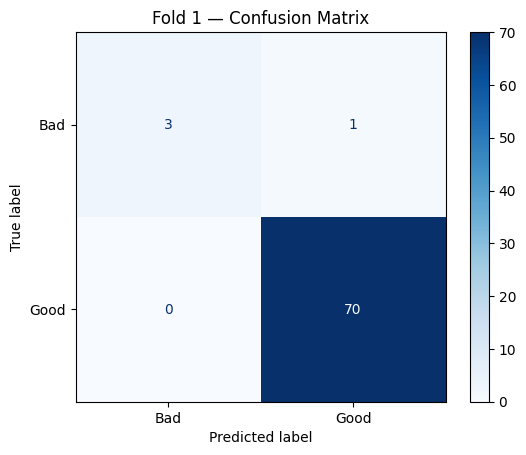

F1 Score: 0.6053489889106327



=== Fold 1 ===
Direct:
 MAE=133.23,
 RMSE=226.25,
 R²=0.58

Hybrid:
 MAE=133.37,
 RMSE=229.17,
 R²=0.56
Pearson correlation (Physics vs True PullForce): 0.7639


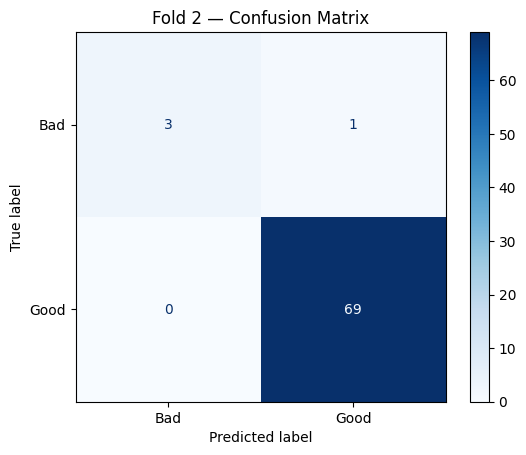

F1 Score: 0.6029556650246305



=== Fold 2 ===
Direct:
 MAE=151.02,
 RMSE=254.19,
 R²=0.72

Hybrid:
 MAE=150.32,
 RMSE=257.75,
 R²=0.72
Pearson correlation (Physics vs True PullForce): 0.7140


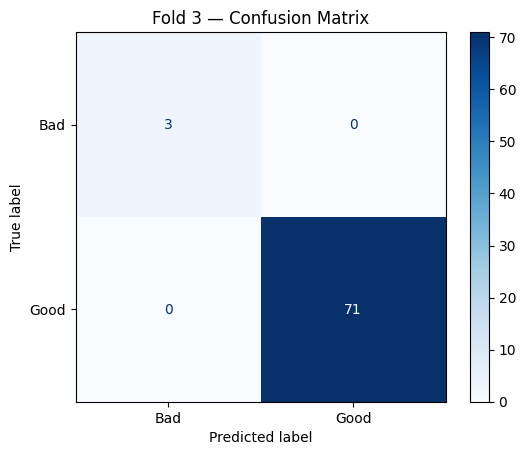

F1 Score: 0.655328798185941



=== Fold 3 ===
Direct:
 MAE=109.00,
 RMSE=166.53,
 R²=0.79

Hybrid:
 MAE=107.56,
 RMSE=162.94,
 R²=0.80
Pearson correlation (Physics vs True PullForce): 0.7306


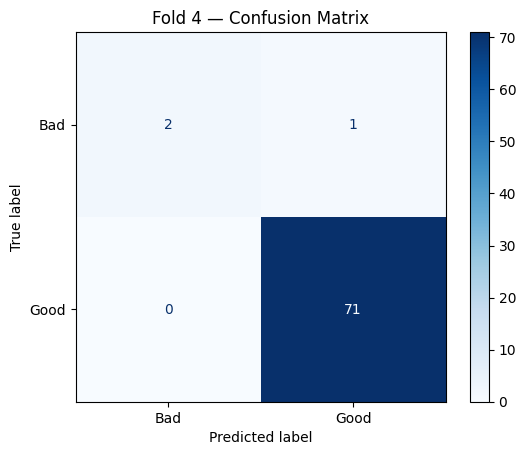

F1 Score: 0.5864864864864865



=== Fold 4 ===
Direct:
 MAE=126.71,
 RMSE=194.91,
 R²=0.76

Hybrid:
 MAE=123.08,
 RMSE=185.49,
 R²=0.78
Pearson correlation (Physics vs True PullForce): 0.7539


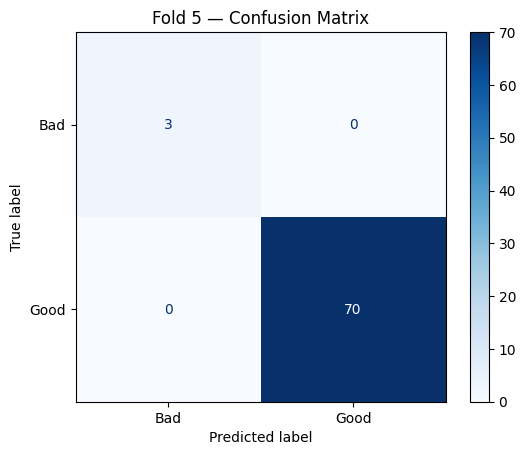

F1 Score: 0.6551724137931035



=== Fold 5 ===
Direct:
 MAE=143.88,
 RMSE=249.58,
 R²=0.70

Hybrid:
 MAE=140.61,
 RMSE=240.77,
 R²=0.72
Pearson correlation (Physics vs True PullForce): 0.7205

=== FINAL CROSS‑VALIDATION RESULTS ===

--- Direct Model ---
MAE mean: 132.77
RMSE mean: 218.29
R² mean: 0.71

--- Hybrid Model (Physics as Feature) ---
MAE mean: 130.99
RMSE mean: 215.22
R² mean: 0.72


In [ ]:
cross_df = pd.read_csv("data/train_dev_data.csv")
target_column_regression = "PullTest (N)" 

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

#Metrics with and without physical inference
direct_mae, direct_rmse, direct_r2 = [], [], [] 
hybrid_mae, hybrid_rmse, hybrid_r2 = [], [], [] 

for fold, (train_index, val_index) in enumerate(skf.split(cross_df["Sample ID"], cross_df["Category"])):


    # Build fold-specific data
    train_df = cross_df.iloc[train_index].copy()
    val_df   = cross_df.iloc[val_index].copy()

    # Group targets by Sample ID (SAME as non‑CV pipeline)
    y_train_reg = train_df.groupby("Sample ID")["PullTest (N)"].first()
    y_val_reg   = val_df.groupby("Sample ID")["PullTest (N)"].first()

    # Build feature matrices at Sample ID level
    x_train = train_df.groupby("Sample ID").first()
    x_val   = val_df.groupby("Sample ID").first()

    x_tr_class, y_tr_class = get_features_and_target(x_train, target_column_class)
    x_val_class, y_val_class = get_features_and_target(x_val, target_column_class)

    x_tr_reg, y_tr_reg = get_features_and_target(x_train, target_column_regression)
    x_val_reg, y_val_reg = get_features_and_target(x_val, target_column_regression)

    #Classification
    classifier = TabPFNClassifier()
    classifier.fit(x_tr_class, y_tr_class)

    predictions_class_train = classifier.predict(x_tr_class)
    predictions_class_dev = classifier.predict(x_val_class)

    # Plot classification results for this fold
    plot_visualizer_classification(
        y_true=y_val_class,
        y_pred=predictions_class_dev,
        class_labels=["Bad", "Good"],
        title=f"Fold {fold+1} — Confusion Matrix"
    )


    physics_train = compute_pullforces(x_tr_reg, y_tr_reg, predictions_class_train) 
    physics_val = compute_pullforces(x_val_reg, y_val_reg, predictions_class_dev)
    
    regressor = TabPFNRegressor()
    regressor.fit(x_tr_reg, y_tr_reg)

    # Predict on the test set
    predictions_regression_dev_without_physics = regressor.predict(x_val_reg)

    direct_mae.append(mean_absolute_error(y_val_reg, predictions_regression_dev_without_physics)) 
    direct_rmse.append(np.sqrt(mean_squared_error(y_val_reg, predictions_regression_dev_without_physics))) 
    direct_r2.append(r2_score(y_val_reg, predictions_regression_dev_without_physics))

    # Categories
    categories= cross_df.iloc[val_index]["Category"].values

    plot_visualizer(
        true_vals=y_val_reg,
        pred_vals=predictions_regression_dev_without_physics,
        categories=categories,
        title=f"Fold {fold+1}: True vs Prediction (TabPFN) by Category"
    )

    x_tr_hybrid = x_tr_reg.copy() 
    x_val_hybrid = x_val_reg.copy() 
    
    x_tr_hybrid["Physical_Inference"] = physics_train 
    x_val_hybrid["Physical_Inference"] = physics_val 
    
    hybrid_model = TabPFNRegressor() 
    hybrid_model.fit(x_tr_hybrid, y_train_reg) 
    
    hybrid_pred = hybrid_model.predict(x_val_hybrid) 
    hybrid_mae.append(mean_absolute_error(y_val_reg, hybrid_pred)) 
    hybrid_rmse.append(np.sqrt(mean_squared_error(y_val_reg, hybrid_pred))) 
    hybrid_r2.append(r2_score(y_val_reg, hybrid_pred))  

    plot_visualizer(
        true_vals=y_val_reg,
        pred_vals=hybrid_pred,
        categories=categories,
        title=f"Fold {fold+1}: True vs Prediction (TabPFN) by Category with Physical Inference"
    )

    print(f"\n=== Fold {fold+1} ===") 
    print(f"Direct:\n MAE={direct_mae[-1]:.2f},\n RMSE={direct_rmse[-1]:.2f},\n R²={direct_r2[-1]:.2f}\n")
    print(f"Hybrid:\n MAE={hybrid_mae[-1]:.2f},\n RMSE={hybrid_rmse[-1]:.2f},\n R²={hybrid_r2[-1]:.2f}")

    corr = np.corrcoef(physics_train, y_train_reg)[0,1] 
    print(f"Pearson correlation (Physics vs True PullForce): {corr:.4f}")

print("\n=== FINAL CROSS‑VALIDATION RESULTS ===") 
print("\n--- Direct Model ---") 
print(f"MAE mean: {np.mean(direct_mae):.2f}") 
print(f"RMSE mean: {np.mean(direct_rmse):.2f}") 
print(f"R² mean: {np.mean(direct_r2):.2f}")

print("\n--- Hybrid Model (Physics as Feature) ---") 
print(f"MAE mean: {np.mean(hybrid_mae):.2f}") 
print(f"RMSE mean: {np.mean(hybrid_rmse):.2f}") 
print(f"R² mean: {np.mean(hybrid_r2):.2f}") 